In [ ]:
%pip install -q -e .. matplotlib

# 02 - Indexing and fetching

Use EDR query options and xarray indexing on an explicitly selected collection
and variable.

## 1. Set the server

In [1]:
import httpx
import xarray as xr

import edr_xarray  # registers engine="edr"

server = "http://127.0.0.1:8000"

## 2. List collections

Run this cell, then choose one collection id in the next cell.

In [2]:
response = httpx.get(f"{server}/collections", timeout=30.0)
response.raise_for_status()
collections = response.json()["collections"]

for collection in collections:
    print(collection["id"], "-", collection.get("title", ""))

EO:EUM:DAT:0398 - msg_frm


## 3. Choose a collection

In [3]:
collection_id = "EO:EUM:DAT:0398"  # Change this to one of the ids listed above.
collection_url = f"{server}/collections/{collection_id}"
collection_url

'http://127.0.0.1:8000/collections/EO:EUM:DAT:0398'

## 4. Open with EDR filters

Leave these as `None`, or replace them with values your server accepts.

In [7]:
bbox = (-3.5, 50.2, -2.1, 51.0)
datetime = "2024-01-01T00:00:00Z/2024-01-02T00:00:00Z"
parameter_names = ["FWI"]

ds = xr.open_dataset(
    collection_url,
    engine="edr",
    bbox=bbox,
    datetime=datetime,
    parameter_names=parameter_names,
)

ds

<xarray.Dataset> Size: 812kB
Dimensions:  (t: 746, y: 9, x: 15)
Coordinates:
  * t        (t) datetime64[ns] 6kB 2024-01-01T12:00:00 ... 2026-01-15T12:00:00
  * y        (y) float64 72B 50.2 50.3 50.4 50.5 50.6 50.7 50.8 50.9 51.0
  * x        (x) float64 120B -3.5 -3.4 -3.3 -3.2 -3.1 ... -2.4 -2.3 -2.2 -2.1
Data variables:
    FWI      (t, y, x) float64 806kB ...
Attributes:
    Conventions:  CF-1.10
    title:        msg_frm
    summary:      FireCube product 'lsasaf-fire-risk-map.msg-seviri-0-degree....

## 5. List variables and dimensions

In [8]:
print("sizes:")
print(dict(ds.sizes))
print()
print("data variables:")
print(list(ds.data_vars))

sizes:
{'t': 746, 'y': 9, 'x': 15}

data variables:
['FWI']


## 6. Choose a variable

In [9]:
variable = "FWI"  # Change this to one of the data variables listed above.
data = ds[variable]

data

<xarray.DataArray 'FWI' (t: 746, y: 9, x: 15)> Size: 806kB
[100710 values with dtype=float64]
Coordinates:
  * t        (t) datetime64[ns] 6kB 2024-01-01T12:00:00 ... 2026-01-15T12:00:00
  * y        (y) float64 72B 50.2 50.3 50.4 50.5 50.6 50.7 50.8 50.9 51.0
  * x        (x) float64 120B -3.5 -3.4 -3.3 -3.2 -3.1 ... -2.4 -2.3 -2.2 -2.1
Attributes:
    standard_name:  FWI
    long_name:      FWI

## 7. Build a lazy subset

Change `indexer` to dimensions shown in `data.sizes`. `isel` uses
zero-based positions, so the largest valid integer position is `size - 1`.
This cell does not fetch values.

In [10]:
print(dict(data.sizes))

indexer = {"t": 0, "y": slice(0, 10), "x": slice(0, 10)}
subset = data.isel(indexer)

subset

{'t': 746, 'y': 9, 'x': 15}


<xarray.DataArray 'FWI' (y: 9, x: 10)> Size: 720B
[90 values with dtype=float64]
Coordinates:
  * y        (y) float64 72B 50.2 50.3 50.4 50.5 50.6 50.7 50.8 50.9 51.0
  * x        (x) float64 80B -3.5 -3.4 -3.3 -3.2 -3.1 -3.0 -2.9 -2.8 -2.7 -2.6
    t        datetime64[ns] 8B 2024-01-01T12:00:00
Attributes:
    standard_name:  FWI
    long_name:      FWI

## 8. Fetch the subset

In [11]:
loaded = subset.load()
loaded

<xarray.DataArray 'FWI' (y: 9, x: 10)> Size: 720B
array([[       nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan],
       [0.70999998,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan],
       [       nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan],
       [       nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan],
       [0.29333332, 0.41999999,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan],
       [0.1725    , 0.19      , 0.21833333, 0.245     , 0.45999998,
        0.53999996,        nan, 0.52333331, 0.43000001, 0.38      ],
       [0.0875    , 0.09999999, 0.095     , 0.16499999, 0.32749999,
        0.41333333, 0.435     , 0.41749999, 0.36750001, 0.31      ],
       [0.08666667, 0.09999999, 0.09      , 0.13499999, 0.23499998,
        0.32999998, 0.34      , 0.35999998, 0.33499998, 0.26999998],
       [0.084     , 0.09      , 0.095     , 0.1275    , 0.2225    ,
        0.34666666, 0.36750001, 0.37      , 0.31999999, 0.22      ]])
Coordinates:
  * y        (y) float64 72B 50.2 50.3 50.4 50.5 50.6 50.7 50.8 50.9 51.0
  * x        (x) float64 80B -3.5 -3.4 -3.3 -3.2 -3.1 -3.0 -2.9 -2.8 -2.7 -2.6
    t        datetime64[ns] 8B 2024-01-01T12:00:00
Attributes:
    standard_name:  FWI
    long_name:      FWI

## 9. Plot when the subset shape supports it

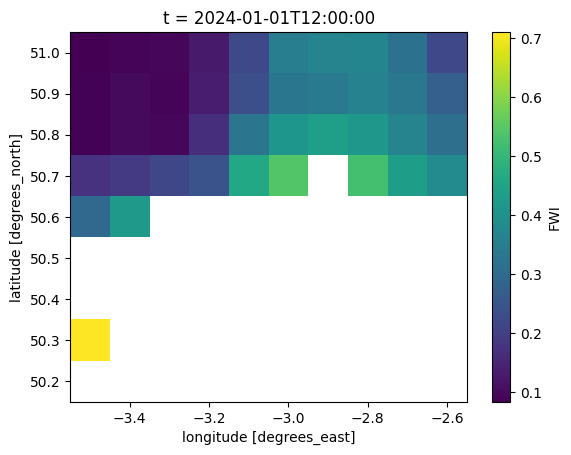

In [12]:
plot_data = loaded
while plot_data.ndim > 2:
    plot_data = plot_data.isel({plot_data.dims[0]: 0})

if plot_data.ndim == 2:
    plot_data.plot()
elif plot_data.ndim == 1:
    plot_data.plot.line(marker="o")
else:
    print(plot_data.item())

## 10. Close resources

In [ ]:
ds.close()